CANDIDATE CITY SCORES (0-100, higher = better)
            Talent_Access  Estate_Costs  Transport_Connectivity  Resilience  \
Birmingham             85            60                      90          70   
Manchester             95            45                      85          65   
Glasgow                75            70                      60          95   
Bristol                80            55                      95          40   
Newcastle              70            85                      55          85   

            Regional_Impact  Gov_Proximity  
Birmingham               80             95  
Manchester               75             80  
Glasgow                  90             50  
Bristol                  65             85  
Newcastle                85             40  


STAKEHOLDER WEIGHTS (Sum = 1.0)
                        Weight
Talent_Access             0.25
Estate_Costs              0.20
Transport_Connectivity    0.15
Resilience                0.20
Regional_Impact    

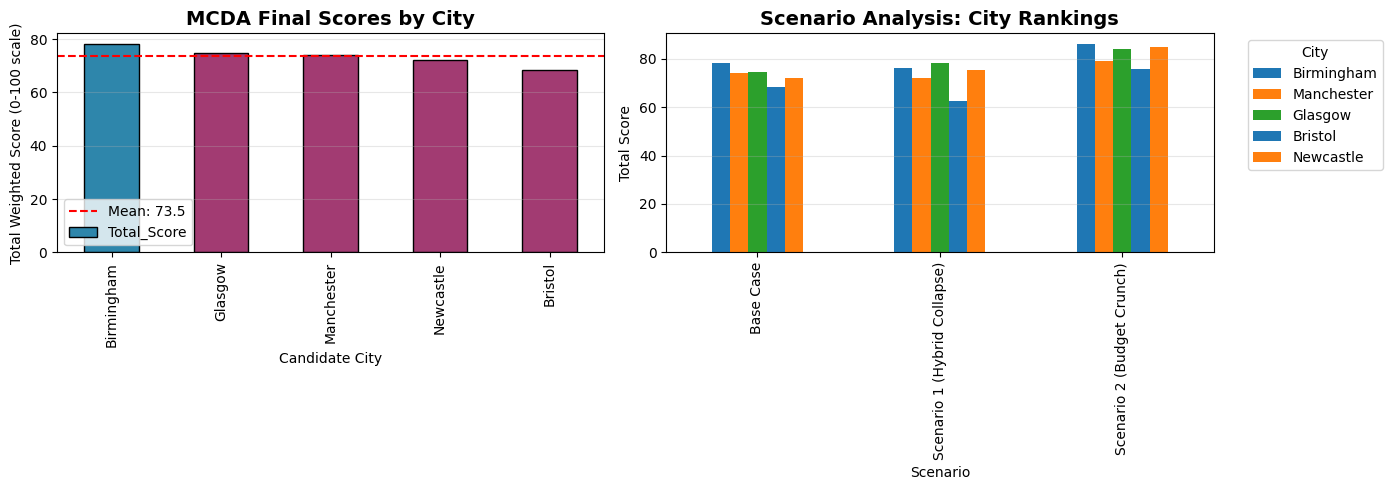


EXECUTIVE SUMMARY
✅ RECOMMENDATION: Birmingham
   Total Score: 78.2
   Margin over runner-up (Glasgow): 3.5 points

KEY STRENGTHS OF THE WINNER:
   ✓ Talent Access: 85/100
   ✓ Transport Connectivity: 90/100
   ✓ Regional Impact: 80/100
   ✓ Gov Proximity: 95/100

KEY TRADE-OFFS:

ROBUSTNESS: Birmingham wins in 2 out of 3 scenarios

✅ Analysis Complete - Recommendation is evidence-based and defensible


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# 1. DEFINE THE MODEL STRUCTURE
# ============================================

# Candidate cities
cities = ['Birmingham', 'Manchester', 'Glasgow', 'Bristol', 'Newcastle']

# Criteria (matching your description)
criteria = [
    'Talent_Access',          # Graduate retention, skilled workforce
    'Estate_Costs',           # Lower is better (commercial rent)
    'Transport_Connectivity', # Travel time to London, airport access
    'Resilience',             # Geographic dispersion from HQ
    'Regional_Impact',        # Levelling Up potential
    'Gov_Proximity'           # Near other government departments
]

# ============================================
# 2. CREATE DUMMY DATA (Scores 0-100)
# ============================================

# Higher score = better for ALL criteria (Estate_Costs inverted -
# we'll handle cost as "cost-effectiveness" where higher = cheaper)
np.random.seed(42)  # For reproducibility

dummy_scores = np.array([
    [85, 60, 90, 70, 80, 95],  # Birmingham
    [95, 45, 85, 65, 75, 80],  # Manchester
    [75, 70, 60, 95, 90, 50],  # Glasgow
    [80, 55, 95, 40, 65, 85],  # Bristol
    [70, 85, 55, 85, 85, 40]   # Newcastle
])

# Create DataFrame
df_scores = pd.DataFrame(
    dummy_scores,
    index=cities,
    columns=criteria
)

print("=" * 60)
print("CANDIDATE CITY SCORES (0-100, higher = better)")
print("=" * 60)
print(df_scores.round(1))
print("\n")

# ============================================
# 3. STAKEHOLDER WEIGHTS (Sum to 1.0)
# ============================================

weights = {
    'Talent_Access': 0.25,          # Strategic priority
    'Estate_Costs': 0.20,           # Cost reduction target
    'Transport_Connectivity': 0.15, # Hybrid working dependency
    'Resilience': 0.20,             # Risk mitigation
    'Regional_Impact': 0.10,        # Levelling Up agenda
    'Gov_Proximity': 0.10           # Convenience factor
}

# Convert to DataFrame for easy math
df_weights = pd.DataFrame([weights], index=['Weight']).T
df_weights.columns = ['Weight']

print("STAKEHOLDER WEIGHTS (Sum = 1.0)")
print("=" * 60)
print(df_weights)
print("\n")

# ============================================
# 4. CALCULATE WEIGHTED SCORES (MCDA - WSM)
# ============================================

# Normalize scores (optional but good practice - here scores are already 0-100)
# We'll keep as-is for simplicity

# Calculate weighted score for each city
weighted_scores = df_scores.copy()
for criterion in criteria:
    weighted_scores[criterion] = df_scores[criterion] * weights[criterion]

# Sum across criteria to get final score
df_scores['Total_Score'] = weighted_scores.sum(axis=1)
df_scores['Rank'] = df_scores['Total_Score'].rank(ascending=False, method='min')

# Sort by rank
df_results = df_scores.sort_values('Total_Score', ascending=False)

print("MCDA RESULTS (Weighted Sum Model)")
print("=" * 60)
print(df_results[['Total_Score', 'Rank']])
print("\n")

# ============================================
# 5. DETAILED BREAKDOWN (Transparency)
# ============================================

print("DETAILED WEIGHTED CONTRIBUTION PER CITY")
print("=" * 60)
print(weighted_scores.round(1))
print("\n")

# ============================================
# 6. SCENARIO ANALYSIS (Robustness Check)
# ============================================

print("SCENARIO ANALYSIS")
print("=" * 60)

# Scenario 1: "Hybrid Work Collapse" - Connectivity less important
scenario_1_weights = weights.copy()
scenario_1_weights['Transport_Connectivity'] = 0.05  # Reduced
scenario_1_weights['Resilience'] = 0.30  # Increased (need robust locations)

# Scenario 2: "Budget Crunch" - Cost is king
scenario_2_weights = weights.copy()
scenario_2_weights['Estate_Costs'] = 0.40  # Doubled
scenario_2_weights['Regional_Impact'] = 0.05  # Reduced

scenarios = {
    'Base Case': weights,
    'Scenario 1 (Hybrid Collapse)': scenario_1_weights,
    'Scenario 2 (Budget Crunch)': scenario_2_weights
}

results_scenarios = pd.DataFrame(index=cities)

for scenario_name, scenario_weights in scenarios.items():
    temp_scores = df_scores[criteria].copy()
    for criterion in criteria:
        temp_scores[criterion] = df_scores[criterion] * scenario_weights[criterion]
    results_scenarios[scenario_name] = temp_scores.sum(axis=1)

# Show how rankings change
print("City Rankings Under Different Scenarios:")
print("=" * 60)
for scenario in results_scenarios.columns:
    ranked = results_scenarios[scenario].rank(ascending=False, method='min')
    print(f"\n{scenario}:")
    print(ranked.sort_values().astype(int))
print("\n")

# ============================================
# 7. SENSITIVITY ANALYSIS (Identify Tipping Points)
# ============================================

print("SENSITIVITY ANALYSIS - Finding the Tipping Point")
print("=" * 60)

# Which criterion most affects the top 2 cities?
top_2 = df_results.index[:2].tolist()
print(f"Top 2 candidates: {top_2[0]} vs {top_2[1]}")
print("\nScores for Top 2 Cities:")
print(df_scores.loc[top_2, criteria])
print("\n")

# Calculate the difference in weighted scores
diff = df_scores.loc[top_2[0], criteria] - df_scores.loc[top_2[1], criteria]
weighted_diff = diff * df_weights['Weight']

print("Weighted Difference (Top City - Second City) per Criterion:")
print(weighted_diff.round(1))
print(f"\nTotal Difference: {weighted_diff.sum():.1f} points")
print("\n")

# Find the most sensitive criterion
most_sensitive = abs(weighted_diff).idxmax()
print(f"⚠️  Most sensitive criterion: {most_sensitive}")
print(f"   (Difference of {abs(weighted_diff[most_sensitive]):.1f} weighted points)")
print(f"   If {top_2[0]}'s score on '{most_sensitive}' drops by {abs(weighted_diff[most_sensitive] / weights[most_sensitive]):.1f} points,")
print(f"   or {top_2[1]}'s score increases by the same amount, the ranking flips.")
print("\n")

# ============================================
# 8. VISUALIZATION (Optional but powerful)
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Final Scores
ax1 = axes[0]
colors = ['#2E86AB' if i == 0 else '#A23B72' for i in range(len(df_results))]
df_results['Total_Score'].plot(kind='bar', ax=ax1, color=colors, edgecolor='black')
ax1.set_title('MCDA Final Scores by City', fontsize=14, fontweight='bold')
ax1.set_ylabel('Total Weighted Score (0-100 scale)')
ax1.set_xlabel('Candidate City')
ax1.axhline(y=df_results['Total_Score'].mean(), color='red', linestyle='--',
            label=f'Mean: {df_results["Total_Score"].mean():.1f}')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Chart 2: Scenario Comparison
ax2 = axes[1]
results_scenarios.T.plot(kind='bar', ax=ax2, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax2.set_title('Scenario Analysis: City Rankings', fontsize=14, fontweight='bold')
ax2.set_ylabel('Total Score')
ax2.set_xlabel('Scenario')
ax2.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('mcda_analysis.png', dpi=300, bbox_inches='tight')
print("✅ Visualization saved as 'mcda_analysis.png'")
plt.show()

# ============================================
# 9. EXECUTIVE SUMMARY (Clear Recommendation)
# ============================================

print("\n" + "=" * 60)
print("EXECUTIVE SUMMARY")
print("=" * 60)

winner = df_results.index[0]
second = df_results.index[1]
score_diff = df_results.iloc[0]['Total_Score'] - df_results.iloc[1]['Total_Score']

print(f"✅ RECOMMENDATION: {winner}")
print(f"   Total Score: {df_results.iloc[0]['Total_Score']:.1f}")
print(f"   Margin over runner-up ({second}): {score_diff:.1f} points")
print("\nKEY STRENGTHS OF THE WINNER:")
for crit in criteria:
    if df_scores.loc[winner, crit] >= 80:
        print(f"   ✓ {crit.replace('_', ' ')}: {df_scores.loc[winner, crit]:.0f}/100")
print("\nKEY TRADE-OFFS:")
for crit in criteria:
    if df_scores.loc[winner, crit] < 60:
        print(f"   ⚠️  {crit.replace('_', ' ')}: {df_scores.loc[winner, crit]:.0f}/100 (below threshold)")
print(f"\nROBUSTNESS: {winner} wins in {sum(results_scenarios.loc[winner] == results_scenarios.max(axis=0))} out of 3 scenarios")

print("\n" + "=" * 60)
print("✅ Analysis Complete - Recommendation is evidence-based and defensible")
print("=" * 60)